# Defensive shape, compactness, press zones and annotated examples: Barça vs Atlético (first half)

Standalone. Reads only the tables exported by section 16 of `football_buildup_pressure_ordered_v6.ipynb` (v6 does not need to change) and the annotated clips from section 14.

Heights are metres from a team's *own* goal (the team always attacks towards +x). Player positions (CB / CM / ST) are inferred, not official.

1. Load the export
2. Frame-level shape table (cached)
3. Averaged stats for every metric, per team, pressed vs free
4. Press zone, pressing episodes, who presses, heatmap
5. Index the annotated clips
6. Annotated frame examples for every metric (low / typical / high)

## 1. Load the export

In [1]:
# ================================================================== 1. Load the export from the pipeline notebook (section 16)
# Nothing is recomputed from the video or the raw tracking tables. Everything here comes from pressure_stats_input/.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import ConvexHull

NOTEBOOK_DIR = Path("C:/Users/user/Desktop/Football_cv_project/football-pipeline (1)/project/new/press")
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd()
OUT_DIR = NOTEBOOK_DIR / "buildup_output"
INPUT_DIR = OUT_DIR / "pressure_stats_input"                 # written by section 16 of the pipeline notebook
STATS_DIR = OUT_DIR / "shape_press_stats"; STATS_DIR.mkdir(parents=True, exist_ok=True)   # everything this notebook writes goes here

NAMES = ["buildups", "frames", "defenders", "positions", "spells", "roster"]
missing = [n for n in NAMES if not (INPUT_DIR / f"{n}.parquet").exists()] + ([] if (INPUT_DIR / "meta.json").exists() else ["meta.json"])
assert not missing, f"not found in {INPUT_DIR}: {missing}. Run section 16 of the pipeline notebook first (and check NOTEBOOK_DIR)."
T = {n: pd.read_parquet(INPUT_DIR / f"{n}.parquet") for n in NAMES}
with open(INPUT_DIR / "meta.json") as f_:
    meta = json.load(f_)
buildups, frames, defenders, positions, spells, roster = (T[n] for n in NAMES)
buildups = buildups.sort_values("start_frame").reset_index(drop=True)

FPS = int(meta["fps"]); L, W = float(meta["pitch_length"]), float(meta["pitch_width"])
TEAM_NAMES = {int(k): v for k, v in meta["team_names"].items()}
TEAM_ATTACKS_POSITIVE_X = {int(k): bool(v) for k, v in meta["team_attacks_positive_x"].items()}
if "team" not in buildups:                                       # older exports: rebuild the team id from the name
    buildups["team"] = buildups["team_name"].map({v: k for k, v in TEAM_NAMES.items()})

def own_frame(x, y, team):
    """Pitch coordinates seen from each player's OWN team: x = metres from own goal (own team always attacks towards +x), y mirrored the same way."""
    pos = np.asarray(pd.Series(team).map(TEAM_ATTACKS_POSITIVE_X).astype(bool))
    x, y = np.asarray(x, float), np.asarray(y, float)
    return np.where(pos, x, L - x), np.where(pos, y, W - y)

def bool_runs(mask, frames_):
    """Inclusive (start_i, end_i) index pairs of True runs; runs never span a jump in `frames_`."""
    mask = np.asarray(mask, bool); frames_ = np.asarray(frames_)
    if len(mask) == 0:
        return []
    brk = np.r_[True, (np.diff(frames_) != 1) | (mask[1:] != mask[:-1])]
    starts = np.flatnonzero(brk); ends = np.r_[starts[1:] - 1, len(mask) - 1]
    return [(int(s), int(e)) for s, e in zip(starts, ends) if mask[s]]

# ------------------------------------------------------------------ check
need = {"positions": ["frame_idx", "track_id", "team", "role", "x", "y"],
        "frames": ["frame_idx", "poss_team", "under_pressure", "n_pressing", "x", "y", "x_att", "y_att", "spell_id"],
        "defenders": ["frame_idx", "track_id", "is_press"], "roster": ["track_id", "team", "name", "number", "position"]}
for n, cols in need.items():
    gap = [c for c in cols if c not in T[n].columns]
    assert not gap, f"{n}: columns missing {gap} (found {list(T[n].columns)})"
print("input folder:", INPUT_DIR)
print(f"teams {TEAM_NAMES} | attacks towards +x {TEAM_ATTACKS_POSITIVE_X} | {FPS} fps | pitch {L:.0f} x {W:.0f} m")
for n in NAMES:
    print(f"  {n:10s} {len(T[n]):>10,} rows")
print("\nbuild-ups by team and outcome:"); print(buildups.groupby(["team_name", "outcome"]).size().unstack(fill_value=0).to_string())

po = positions[positions.role == "player"]
cnt = po.groupby(["frame_idx", "team"]).size().unstack()
print("\noutfield players tracked per frame (the shape stats need most of the 10):")
print(cnt.rename(columns=TEAM_NAMES).describe().loc[["mean", "min", "25%", "50%", "max"]].round(1).to_string())
print("share of possession frames with >= 8 outfield players tracked:", (cnt >= 8).mean().rename(TEAM_NAMES).round(3).to_dict())
print("position labels in the roster are INFERRED, not official:", sorted(roster.position.dropna().unique()))


input folder: C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\pressure_stats_input
teams {0: 'ATM', 1: 'BAR'} | attacks towards +x {0: False, 1: True} | 25 fps | pitch 105 x 68 m
  buildups          181 rows
  frames         52,561 rows
  defenders     508,077 rows
  positions   1,060,375 rows
  spells            199 rows
  roster             22 rows

build-ups by team and outcome:
outcome    dead_or_untracked  lost  success
team_name                                  
ATM                       26    52       13
BAR                       19    25       46

outfield players tracked per frame (the shape stats need most of the 10):
team   ATM   BAR
mean   9.7   9.6
min    1.0   1.0
25%   10.0  10.0
50%   10.0  10.0
max   10.0  10.0
share of possession frames with >= 8 outfield players tracked: {'ATM': 0.972, 'BAR': 0.963}
position labels in the roster are INFERRED, not official: ['CB', 'CM', 'GK', 'LB', 'LM', 'LW', 'RB', 'RM', 'RW', 'ST']


## 2. Frame-level shape table

In [2]:
# ================================================================== 2. Frame-level shape table (cached: heavy part, run once)
# For every sampled frame inside a build-up, in each team's OWN frame (x = metres from its own goal, own team attacks towards +x):
#   DEFENDING team (the one pressing):  def_line_height   mean distance from own goal of the 4 deepest outfield players (back line)
#                                       def_last_man      deepest outfield player
#                                       def_block_height  mean of all outfield players;  def_front_height  mean of the 3 highest
#                                       def_depth / def_width / def_hull_area / def_spread   team length, width, convex hull area, mean distance to the centroid
#                                       press_height_m    distance from the defending team's own goal to the ball carrier (= where the press happens)
#                                       line_to_ball_m    press_height_m - def_line_height (space between the back line and the ball)
#                                       gap_back_mid      back 4 -> middle 3 spacing;  gap_mid_front  middle 3 -> front 3 spacing (the 3 + 4 + 3 split is by height, not by role)
#                                       def_n_local       defenders within R_LOCAL m of the ball;  local_superiority = defenders minus build-up players within R_LOCAL m
#                                       min_dist, n_pressing   from the pressure measurement (nearest defender to the carrier, pressing defenders)
#   BUILD-UP team:                      att_depth / att_width / att_hull_area
# A metric is only computed when at least MIN_TRACKED outfield players of that team are tracked in the frame: a missing deep defender would
# make the line look higher than it is.
STEP_FRAMES = 2          # sample every 2nd frame (12.5 fps); 1 = every frame
MIN_TRACKED = 8          # outfield players (of 10) that must be tracked in that team for its metrics to count
R_LOCAL = 15.0           # radius around the ball for the local counts (m)
REBUILD = False          # True = ignore the cache

cache, cache_meta = STATS_DIR / "frame_shape.parquet", STATS_DIR / "frame_shape_meta.json"
key = dict(version=2, r_local=R_LOCAL, step=STEP_FRAMES, min_tracked=MIN_TRACKED, n_buildups=int(len(buildups)), last_end=int(buildups.end_frame.max()), n_pos=int(len(positions)))
pr_i = frames.drop_duplicates("frame_idx").set_index("frame_idx").sort_index()
pr_i["poss_team"] = pr_i["poss_team"].astype(int)

def hull_area(xy):
    if len(xy) < 3:
        return np.nan
    try:
        return float(ConvexHull(xy).volume)           # in 2D, .volume is the area
    except Exception:
        return np.nan

if cache.exists() and cache_meta.exists() and json.load(open(cache_meta)) == key and not REBUILD:
    fs = pd.read_parquet(cache)
    print("loaded from cache:", cache)
else:
    avail = pr_i.index.to_numpy()
    parts = []
    for b in buildups.itertuples():
        fr = np.arange(b.start_frame, b.end_frame + 1, STEP_FRAMES)
        parts.append(pd.DataFrame(dict(frame_idx=fr[np.isin(fr, avail)], buildup_id=b.buildup_id)))
    samp = pd.concat(parts).drop_duplicates("frame_idx")
    pp = positions[(positions.role == "player") & positions.frame_idx.isin(samp.frame_idx)].merge(samp, on="frame_idx")
    pp["poss_team"] = pp.frame_idx.map(pr_i["poss_team"]).astype(int)
    pp["x_own"], pp["y_own"] = own_frame(pp.x, pp.y, pp.team)
    rows = []
    for f, g in pp.groupby("frame_idx", sort=False):
        p = int(g.poss_team.iat[0]); d = 1 - p
        tm = g.team.to_numpy(); xo, yo = g.x_own.to_numpy(), g.y_own.to_numpy()
        dist_ball = np.hypot(g.x.to_numpy() - pr_i.at[f, "x"], g.y.to_numpy() - pr_i.at[f, "y"])      # raw pitch metres to the press target (carrier, else ball)
        r = dict(frame_idx=int(f), buildup_id=int(g.buildup_id.iat[0]), poss_team=p, def_team=d, n_def=int((tm == d).sum()), n_att=int((tm == p).sum()))
        m = tm == d
        if m.sum() >= MIN_TRACKED:
            xs = np.sort(xo[m]); ys = yo[m]
            r.update(def_line_height=xs[:4].mean(), def_last_man=xs[0], def_block_height=xs.mean(), def_front_height=xs[-3:].mean(),
                     def_depth=xs[-1] - xs[0], def_width=ys.max() - ys.min(), def_hull_area=hull_area(np.c_[xo[m], yo[m]]),
                     def_spread=float(np.hypot(xo[m] - xo[m].mean(), yo[m] - yo[m].mean()).mean()))
            if len(xs) >= 9:                                          # middle 3 needs at least 2 players left after the back 4 and front 3
                mid = xs[4:-3].mean(); r.update(gap_back_mid=mid - xs[:4].mean(), gap_mid_front=xs[-3:].mean() - mid)
        m = tm == p
        if m.sum() >= MIN_TRACKED:
            r.update(att_depth=xo[m].max() - xo[m].min(), att_width=yo[m].max() - yo[m].min(), att_hull_area=hull_area(np.c_[xo[m], yo[m]]))
        if (tm == d).sum() >= MIN_TRACKED and (tm == p).sum() >= MIN_TRACKED:
            nd, na = int(((tm == d) & (dist_ball < R_LOCAL)).sum()), int(((tm == p) & (dist_ball < R_LOCAL)).sum())
            r.update(def_n_local=nd, att_n_local=na, local_superiority=nd - na)
        rows.append(r)
    fs = pd.DataFrame(rows)
    tgt = pr_i.loc[fs.frame_idx]
    fs["press_height_m"], _ = own_frame(tgt["x"].to_numpy(), tgt["y"].to_numpy(), fs["def_team"])
    fs["line_to_ball_m"] = fs["press_height_m"] - fs["def_line_height"]
    fs["under_pressure"] = tgt["under_pressure"].to_numpy(bool)
    fs["n_pressing"] = tgt["n_pressing"].to_numpy(int)
    fs["min_dist"] = tgt["min_dist"].to_numpy(float) if "min_dist" in tgt else np.nan
    fs.to_parquet(cache); json.dump(key, open(cache_meta, "w"))
    print("built and cached:", cache)

fs["def_team_name"] = fs.def_team.map(TEAM_NAMES); fs["poss_team_name"] = fs.poss_team.map(TEAM_NAMES)
# ------------------------------------------------------------------ check
print(f"{len(fs):,} sampled frames from {fs.buildup_id.nunique()} of {len(buildups)} build-ups (every {STEP_FRAMES} frame(s))")
print(f"frames with a valid defending-block measurement: {fs.def_line_height.notna().mean() * 100:.1f}% | valid build-up-team shape: {fs.att_depth.notna().mean() * 100:.1f}%")
print("\nframe-level distribution, defending team's line height (m from its own goal):")
print(fs.groupby("def_team_name")["def_line_height"].describe(percentiles=[.1, .5, .9]).round(1).to_string())
print(f"line spacing valid in {fs.gap_back_mid.notna().mean() * 100:.1f}% of frames, local counts valid in {fs.local_superiority.notna().mean() * 100:.1f}%")
print("\nsanity: line height should sit between the last man and the block height ->",
      f"{((fs.def_last_man <= fs.def_line_height) & (fs.def_line_height <= fs.def_block_height)).dropna().mean() * 100:.1f}% of frames")


built and cached: C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\shape_press_stats\frame_shape.parquet
18,020 sampled frames from 181 of 181 build-ups (every 2 frame(s))
frames with a valid defending-block measurement: 97.1% | valid build-up-team shape: 98.6%

frame-level distribution, defending team's line height (m from its own goal):
                count  mean   std   min   10%   50%   90%   max
def_team_name                                                  
ATM            9050.0  37.2  11.4  12.4  22.1  36.4  50.9  84.2
BAR            8452.0  52.3  10.9  22.9  38.2  52.3  67.9  89.5
line spacing valid in 95.2% of frames, local counts valid in 96.3%

sanity: line height should sit between the last man and the block height -> 97.1% of frames


## 3. Averaged stats for every metric

In [3]:
# ================================================================== 3. Averaged stats: every metric, per team, and pressed vs not pressed
# Each build-up counts once: per-build-up mean first, then the mean over build-ups. "pressed" = frames flagged under_pressure, "free" = the others.
# The pressed-vs-free comparison is PAIRED inside each build-up (needs STATE_MIN_FRAMES sampled frames in both states), 95% interval by resampling
# build-ups. It describes the shape while the carrier is pressed; it does not prove the shape caused the pressure.
STATE_MIN_FRAMES = 5
N_BOOT = 2000
fs["state"] = np.where(fs.under_pressure, "pressed", "free")

# group: "def" = measured on the DEFENDING team (team column = the team that defends), "att" = on the team BUILDING UP
# pressed_only: averaged over pressed frames only (a count of pressers is 0 in free frames by definition)
# paired: take part in the pressed-vs-free comparison (not for measures that define pressure itself)
# example: gets annotated frame examples in cell 6
METRICS = [
    dict(key="def_line_height",   group="def", unit="m",  label="Defensive line height (m from own goal)",        what="mean distance from own goal of the 4 deepest outfield players"),
    dict(key="def_last_man",      group="def", unit="m",  label="Last man height",                                 what="deepest outfield player", example=False),
    dict(key="def_block_height",  group="def", unit="m",  label="Block height (mean of all outfield players)",     what="mean distance from own goal of all outfield players", example=False),
    dict(key="def_front_height",  group="def", unit="m",  label="Front line height (3 highest players)",          what="mean distance from own goal of the 3 highest players", example=False),
    dict(key="press_height_m",    group="def", unit="m",  label="Press height (carrier distance from the pressing team's goal)", what="where on the pitch the ball is, seen from the defending team's own goal", example=False),
    dict(key="line_to_ball_m",    group="def", unit="m",  label="Space between back line and ball",                what="press height minus line height: the space the defence leaves behind the press"),
    dict(key="def_depth",         group="def", unit="m",  label="Block depth (last man to highest player)",        what="vertical compactness: smaller = more compact"),
    dict(key="def_width",         group="def", unit="m",  label="Block width",                                     what="horizontal spread of the outfield players: smaller = narrower"),
    dict(key="def_hull_area",     group="def", unit="m2", label="Block area (convex hull)",                        what="area covered by the outfield players: smaller = more compact"),
    dict(key="def_spread",        group="def", unit="m",  label="Mean distance to the block centre",               what="compactness: mean distance of each outfield player to the team centroid", example=False),
    dict(key="gap_back_mid",      group="def", unit="m",  label="Gap back 4 to middle 3",                          what="spacing between the back four and the three players above them"),
    dict(key="gap_mid_front",     group="def", unit="m",  label="Gap middle 3 to front 3",                         what="spacing between the middle three and the three highest players"),
    dict(key="def_n_local",       group="def", unit="n",  label="Defenders within 15 m of the ball",              what="how many defenders are near the ball (local compression)"),
    dict(key="local_superiority", group="def", unit="n",  label="Local balance within 15 m (defenders minus build-up players)", what="positive = defenders outnumber the build-up team around the ball"),
    dict(key="min_dist",          group="def", unit="m",  label="Distance carrier to nearest defender",            what="from the pressure measurement", paired=False),
    dict(key="n_pressing",        group="def", unit="n",  label="Pressers (pressed frames only)",                  what="defenders meeting the press rule at the same time", pressed_only=True, paired=False),
    dict(key="att_width",         group="att", unit="m",  label="Build-up team width",                             what="horizontal spread of the team in possession"),
    dict(key="att_depth",         group="att", unit="m",  label="Build-up team depth",                             what="length of the team in possession, last player to highest"),
    dict(key="att_hull_area",     group="att", unit="m2", label="Build-up team area (convex hull)",                what="area covered by the team in possession", example=False),
]
for m in METRICS:
    m.setdefault("pressed_only", False); m.setdefault("paired", True); m.setdefault("example", True)
METRICS = [m for m in METRICS if m["key"] in fs.columns]
tcol = lambda m: "def_team_name" if m["group"] == "def" else "poss_team_name"
team_list = [TEAM_NAMES[k] for k in sorted(TEAM_NAMES)]

def per_buildup(m):
    d = fs[fs.under_pressure] if m["pressed_only"] else fs
    out = d.groupby(["buildup_id", tcol(m)])[m["key"]].mean().reset_index()
    return out.rename(columns={tcol(m): "team", m["key"]: "v"}).dropna(subset=["v"])

# ------------------------------------------------------------------ A. averages per team
rowsA = []
for m in METRICS:
    pb = per_buildup(m); r = dict(metric=m["key"], unit=m["unit"], who="defending team" if m["group"] == "def" else "team building up")
    for t in team_list:
        g = pb[pb.team == t]; r[t] = round(g.v.mean(), 1) if len(g) else np.nan; r[f"n_{t}"] = len(g)
    rowsA.append(r)
tabA = pd.DataFrame(rowsA)
print("A. average per team (mean over build-ups; 'who' says which team the metric describes; n_ = build-ups behind each mean)")
print(tabA.to_string(index=False))

# ------------------------------------------------------------------ B. pressed vs free, paired inside each build-up
rng = np.random.default_rng(1)
def paired(m):
    a = fs.groupby(["buildup_id", tcol(m), "state"]).agg(n=("frame_idx", "size"), v=(m["key"], "mean")).reset_index()
    a = a[(a.n >= STATE_MIN_FRAMES) & a.v.notna()]
    w = a.pivot_table(index=["buildup_id", tcol(m)], columns="state", values="v")
    if not {"pressed", "free"} <= set(w.columns):
        return []
    w = w.dropna(subset=["pressed", "free"]); out = []
    for team, g in list(w.groupby(level=1)) + [("BOTH", w)]:
        if len(g) < 3:
            out.append(dict(metric=m["key"], team=team, n_buildups=len(g))); continue
        d = (g["pressed"] - g["free"]).to_numpy(); bs = d[rng.integers(0, len(d), (N_BOOT, len(d)))].mean(axis=1)
        out.append(dict(metric=m["key"], team=team, n_buildups=len(g), pressed=g["pressed"].mean(), free=g["free"].mean(), diff=d.mean(),
                        ci95=f"{np.percentile(bs, 2.5):.1f} to {np.percentile(bs, 97.5):.1f}"))
    return out

tabB = pd.DataFrame([r for m in METRICS if m["paired"] for r in paired(m)])
for c in ["pressed", "free", "diff"]:
    tabB[c] = tabB[c].round(1)
print(f"\nB. pressed vs free frames, paired inside each build-up (n = build-ups with >= {STATE_MIN_FRAMES} sampled frames in BOTH states)")
print("   team = the team the metric describes (defending team for def_*, gap_*, local_*; team building up for att_*)")
print(tabB.to_string(index=False))

tabA.to_csv(STATS_DIR / "metrics_average_by_team.csv", index=False); tabB.to_csv(STATS_DIR / "metrics_pressed_vs_free.csv", index=False)
print("\nsaved to", STATS_DIR)


A. average per team (mean over build-ups; 'who' says which team the metric describes; n_ = build-ups behind each mean)
           metric unit              who   ATM  n_ATM    BAR  n_BAR
  def_line_height    m   defending team  36.1     90   55.6     90
     def_last_man    m   defending team  32.9     90   50.7     90
 def_block_height    m   defending team  45.3     90   65.5     90
 def_front_height    m   defending team  56.6     90   77.5     90
   press_height_m    m   defending team  57.7     90   75.9     91
   line_to_ball_m    m   defending team  21.6     90   20.5     90
        def_depth    m   defending team  28.3     90   30.6     90
        def_width    m   defending team  39.1     90   38.8     90
    def_hull_area   m2   defending team 743.7     90  801.3     90
       def_spread    m   defending team  14.7     90   14.5     90
     gap_back_mid    m   defending team  10.2     89   11.3     89
    gap_mid_front    m   defending team  10.4     89   10.8     89
      def_

## 4. Press zone and who presses

35,944 build-up frames with a located target, 9,153 of them under pressure (25%)

A. share of each team's pressed frames by zone, % (where it presses the ball):
zone           low block  mid block  high press
def_team_name                                  
ATM                  0.7       79.9        19.3
BAR                  0.0       48.1        51.9

   press rate by zone, % of the opponent's build-up frames in that zone that were under pressure:
zone           low block  mid block  high press
def_team_name                                  
ATM                 39.7       24.4        12.1
BAR                  4.2       35.2        27.4

   zone x channel, share of the team's pressed frames, %:
channel                   centre  y_high  y_low
def_team_name zone                             
ATM           low block      0.2     0.3    0.3
              mid block     28.0    31.3   20.7
              high press     5.5     5.2    8.7
BAR           low block      0.0     0.0    0.0
         

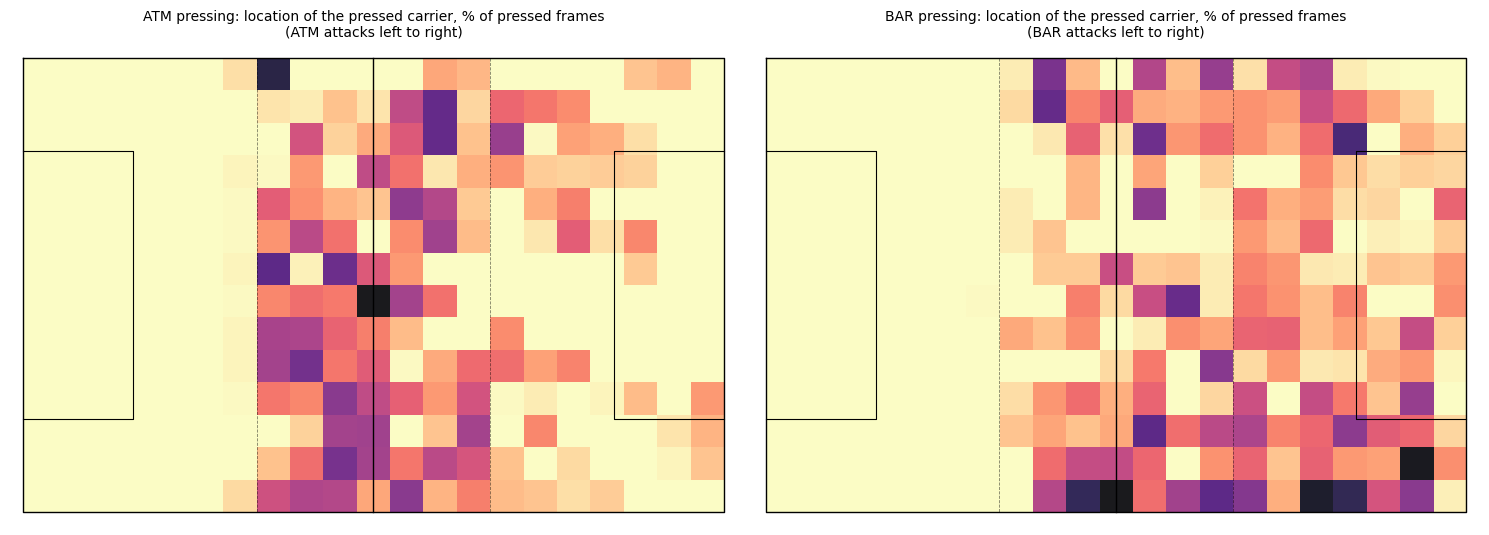


saved to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\shape_press_stats


In [4]:
# ================================================================== 4. Press zone and who presses
# Zones are in the DEFENDING team's own frame: it attacks towards +x. "high press" = the pressed carrier is in the defending team's attacking third
# (i.e. in the pressed team's own third); "low block" = in the defending team's own third. Channels use neutral names (y_low / centre / y_high)
# until you confirm which side is left on the video.
inb = np.zeros(int(frames.frame_idx.max()) + 2, bool)                  # frames that belong to a build-up
for b in buildups.itertuples():
    inb[b.start_frame:b.end_frame + 1] = True
fp = frames.drop_duplicates("frame_idx").sort_values("frame_idx")
fp = fp[inb[fp.frame_idx.to_numpy()] & fp.x_att.notna()].copy()
fp["poss_team"] = fp.poss_team.astype(int); fp["def_team_name"] = (1 - fp.poss_team).map(TEAM_NAMES)
fp["x_def"], fp["y_def"] = L - fp.x_att, W - fp.y_att                  # target location in the defender's own frame
fp["zone"] = np.select([fp.x_def < L / 3, fp.x_def < 2 * L / 3], ["low block", "mid block"], "high press")
fp["channel"] = np.select([fp.y_def < W / 3, fp.y_def > 2 * W / 3], ["y_low", "y_high"], "centre")
fp["under_pressure"] = fp.under_pressure.astype(bool)
ZONES = ["low block", "mid block", "high press"]

pf_ = fp[fp.under_pressure]
print(f"{len(fp):,} build-up frames with a located target, {len(pf_):,} of them under pressure ({len(pf_) / len(fp) * 100:.0f}%)\n")

# ------------------------------------------------------------------ A. where does the press happen
print("A. share of each team's pressed frames by zone, % (where it presses the ball):")
zs = pf_.groupby("def_team_name")["zone"].value_counts(normalize=True).mul(100).round(1).unstack(fill_value=0).reindex(columns=ZONES, fill_value=0)
print(zs.to_string())
print("\n   press rate by zone, % of the opponent's build-up frames in that zone that were under pressure:")
pr_zone = fp.groupby(["def_team_name", "zone"])["under_pressure"].mean().mul(100).round(1).unstack().reindex(columns=ZONES)
print(pr_zone.to_string())
print("\n   zone x channel, share of the team's pressed frames, %:")
zc = pf_.groupby(["def_team_name", "zone", "channel"]).size().div(pf_.groupby("def_team_name").size(), level=0).mul(100).round(1).unstack(fill_value=0)
print(zc.reindex(ZONES, level=1).to_string())

# ------------------------------------------------------------------ B. pressing episodes: where does each one START
ep = []
for sid, g in fp.groupby("spell_id"):
    fr_, up_ = g.frame_idx.to_numpy(), g.under_pressure.to_numpy()
    for s, e in bool_runs(up_, fr_):
        ep.append(dict(def_team_name=g.def_team_name.iat[0], zone=g.zone.iat[s], channel=g.channel.iat[s], dur_s=(e - s + 1) / FPS))
ep = pd.DataFrame(ep)
print(f"\nB. {len(ep)} pressing episodes (runs of 'under pressure'); zone where each episode starts, count:")
print(ep.groupby(["def_team_name", "zone"]).size().unstack(fill_value=0).reindex(columns=ZONES, fill_value=0).to_string())
print("   median episode length (s):", ep.groupby("def_team_name")["dur_s"].median().round(1).to_dict())

# ------------------------------------------------------------------ C. who presses (INFERRED positions)
LINE = {"LB": "defenders", "CB": "defenders", "RB": "defenders", "LM": "midfielders", "CM": "midfielders", "RM": "midfielders",
        "LW": "forwards", "ST": "forwards", "RW": "forwards"}
dm = defenders[defenders.is_press.astype(bool)]
dm = dm[inb[np.clip(dm.frame_idx.to_numpy(), 0, len(inb) - 1)]].merge(roster[["track_id", "team", "name", "number", "position"]], on="track_id", how="left")
dm["line"] = dm.position.map(LINE).fillna("unknown"); dm["team_name"] = dm.team.map(TEAM_NAMES)
print(f"\nC. presser-frames: {len(dm):,} (one row per pressing defender per frame)")
print("   share by line, % of the team's presser-frames (lines come from INFERRED positions):")
print(dm.groupby("team_name")["line"].value_counts(normalize=True).mul(100).round(1).unstack(fill_value=0).to_string())
top = (dm.groupby(["team_name", "number", "name"]).size().div(FPS).round(1).rename("pressing_seconds").reset_index()
         .sort_values(["team_name", "pressing_seconds"], ascending=[True, False]).groupby("team_name").head(5))
print("\n   most pressing seconds per player (a player can be one of several pressers in the same frame):")
print(top.to_string(index=False))

# ------------------------------------------------------------------ D. heatmaps of the press location, defending team attacks left to right
def draw_pitch(ax):
    ax.plot([0, L, L, 0, 0], [0, 0, W, W, 0], "k", lw=1); ax.plot([L / 2] * 2, [0, W], "k", lw=1)
    for x_ in (L / 3, 2 * L / 3):
        ax.plot([x_, x_], [0, W], color="k", lw=0.6, ls="--", alpha=0.5)
    for x0, sgn in ((0, 1), (L, -1)):
        ax.plot([x0, x0 + sgn * 16.5, x0 + sgn * 16.5, x0], [W / 2 - 20.15, W / 2 - 20.15, W / 2 + 20.15, W / 2 + 20.15], "k", lw=0.8)
    ax.set_xlim(-2, L + 2); ax.set_ylim(W + 2, -2); ax.set_aspect("equal"); ax.axis("off")

teams = sorted(pf_.def_team_name.unique())
fig, axes = plt.subplots(1, len(teams), figsize=(7.5 * len(teams), 5.2))
for ax, tn in zip(np.atleast_1d(axes), teams):
    g = pf_[pf_.def_team_name == tn]
    h, xe, ye = np.histogram2d(g.x_def, g.y_def, bins=[21, 14], range=[[0, L], [0, W]])
    ax.imshow((h / h.sum() * 100).T, origin="upper", extent=[0, L, W, 0], cmap="magma_r", aspect="equal", alpha=0.9)
    draw_pitch(ax); ax.set_title(f"{tn} pressing: location of the pressed carrier, % of pressed frames\n({tn} attacks left to right)", fontsize=10)
plt.tight_layout(); png = STATS_DIR / "press_zone_heatmap.png"; plt.savefig(png, dpi=110); plt.show()

zs.to_csv(STATS_DIR / "press_zone_share.csv"); pr_zone.to_csv(STATS_DIR / "press_rate_by_zone.csv"); zc.to_csv(STATS_DIR / "press_zone_by_channel.csv")
dm.groupby("team_name")["line"].value_counts(normalize=True).rename("share").to_csv(STATS_DIR / "pressers_by_line.csv"); top.to_csv(STATS_DIR / "top_pressers.csv", index=False)
print("\nsaved to", STATS_DIR)


## 5. Index the annotated clips

In [5]:
# ================================================================== 5. Index the annotated clips (build-up <-> clip file <-> frame numbers)
# A clip is matched to a build-up by TEAM + START TIME (never by number: build-up numbers shift between runs). The clip window is rebuilt with the same
# rule as render_clip() in section 14 of the pipeline notebook, so a tracking frame becomes a frame of the clip file:  clip_frame = (frame_idx - f0) * SLOWDOWN.
# Must be the same values as in section 14:
import re
import cv2
CLIP_FOLDER = "clips2"                                 # folder of the annotated clips written by section 14 (one sub-folder per category)
CLIP_DIR = OUT_DIR / CLIP_FOLDER
PRE_SEC, POST_SEC, MAX_CLIP_SEC, FREEZE_END_SEC, SLOWDOWN = 2.0, 2.0, 20.0, 1.0, 1
F = lambda sec: int(round(sec * FPS))
mmss = lambda frame: f"{int(frame / FPS) // 60:02d}:{int(frame / FPS) % 60:02d}"
CLIP_RE = re.compile(r"^b(\d+)_(.+)_(\d{2}-\d{2})$")        # b114_ATM_30-20

def clip_window(b):
    anchor = int(b.first_press_frame) if ("first_press_frame" in b._fields and pd.notna(b.first_press_frame)) else int(b.start_frame)
    f1 = int(b.end_frame) + F(POST_SEC)
    return max(0, anchor - F(PRE_SEC), f1 - F(MAX_CLIP_SEC)), f1

by_key = {(r.team_name, r.start_time): r for r in buildups.itertuples()}
rows, unmatched = [], []
for p in sorted(CLIP_DIR.glob("*/*.mp4")) if CLIP_DIR.exists() else []:
    m = CLIP_RE.match(p.stem); b = by_key.get((m.group(2), m.group(3).replace("-", ":"))) if m else None
    if b is None:
        unmatched.append(p); continue
    f0, f1 = clip_window(b)
    cap = cv2.VideoCapture(str(p)); n_clip = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); cap.release()
    n_exp = (f1 - f0 + 1) * SLOWDOWN + F(FREEZE_END_SEC) * SLOWDOWN
    rows.append(dict(buildup_id=int(b.buildup_id), team_name=b.team_name, start_time=b.start_time, outcome=b.outcome, category=p.parent.name,
                     path=p, f0=f0, f1=f1, n_expected=n_exp, n_clip=n_clip))
clip_index = pd.DataFrame(rows)
if len(clip_index):
    clip_index["frames_ok"] = (clip_index.n_clip - clip_index.n_expected).abs() <= 2

print(f"clip folder: {CLIP_DIR}  ({'found' if CLIP_DIR.exists() else 'NOT FOUND'})")
print(f"{len(clip_index)} clips matched to a build-up by team + start time; {len(unmatched)} match no build-up")
if len(clip_index):
    print(f"usable (frame count equals the expected window): {int(clip_index.frames_ok.sum())}")
    bad = clip_index[~clip_index.frames_ok]
    if len(bad):
        print("NOT used for examples (stale or rendered with other settings, frames would be misaligned):")
        print(bad[["buildup_id", "team_name", "start_time", "category", "n_expected", "n_clip"]].to_string(index=False))
    print("\nclips by category:"); print(clip_index.groupby(["category", "team_name"]).size().unstack(fill_value=0).to_string())
for p in unmatched[:10]:
    print("  unmatched:", p.parent.name + "/" + p.name)
print("\nNote: the clips cover only the build-ups selected in section 14 (lost / kept under pressure, lost without pressure); the averages in cell 3 use ALL build-ups.")


clip folder: C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\clips2  (found)
33 clips matched to a build-up by team + start time; 1 match no build-up
usable (frame count equals the expected window): 30
NOT used for examples (stale or rendered with other settings, frames would be misaligned):
 buildup_id team_name start_time            category  n_expected  n_clip
         47       BAR      13:17 kept_under_pressure         388     155
        149       BAR      39:27 kept_under_pressure         465     249
        137       ATM      36:54 lost_under_pressure         296     505

clips by category:
team_name              ATM  BAR
category                       
kept_under_pressure      3   10
lost_under_pressure     11    4
lost_without_pressure    5    0
  unmatched: lost_without_pressure/b159_ATM_44-28.mp4

Note: the clips cover only the build-ups selected in section 14 (lost / kept under pressure, lost without pressure); the averages i

## 6. Annotated frame examples for every metric

3,944 candidate frames from 30 build-ups with a usable clip

Defensive line height (m from own goal)   [def_line_height]
   mean distance from own goal of the 4 deepest outfield players
   average: ATM 36.1 m | BAR 55.6 m   (defending team)


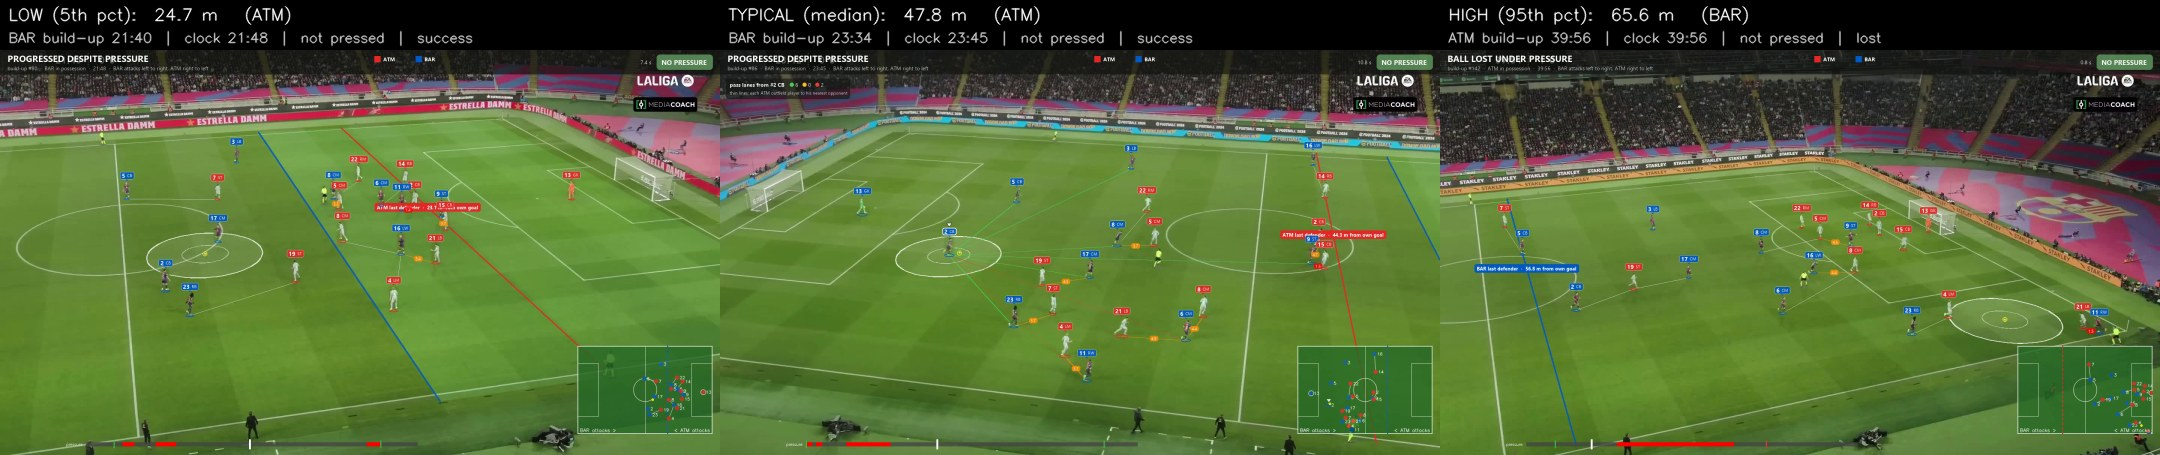

   LOW (5th pct)      kept_under_pressure/b080_BAR_21-40.mp4  clip frame 224  (tracking frame 32700)
   TYPICAL (median)   kept_under_pressure/b086_BAR_23-34.mp4  clip frame 198  (tracking frame 35628)
   HIGH (95th pct)    lost_under_pressure/b142_ATM_39-56.mp4  clip frame 36  (tracking frame 59924)
Space between back line and ball   [line_to_ball_m]
   press height minus line height: the space the defence leaves behind the press
   average: ATM 21.6 m | BAR 20.5 m   (defending team)


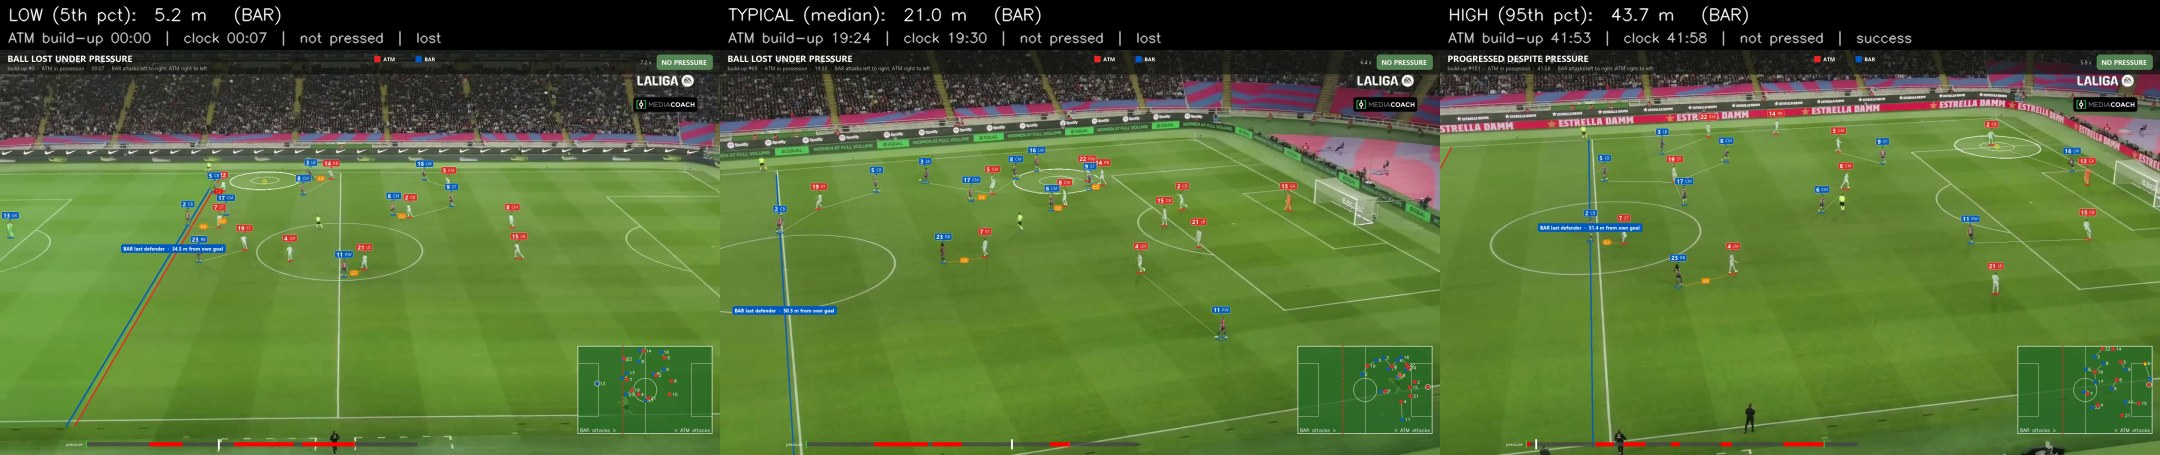

   LOW (5th pct)      lost_under_pressure/b000_ATM_00-00.mp4  clip frame 105  (tracking frame 192)
   TYPICAL (median)   lost_under_pressure/b069_ATM_19-24.mp4  clip frame 151  (tracking frame 29267)
   HIGH (95th pct)    kept_under_pressure/b151_ATM_41-53.mp4  clip frame 15  (tracking frame 62974)
Block depth (last man to highest player)   [def_depth]
   vertical compactness: smaller = more compact
   average: ATM 28.3 m | BAR 30.6 m   (defending team)


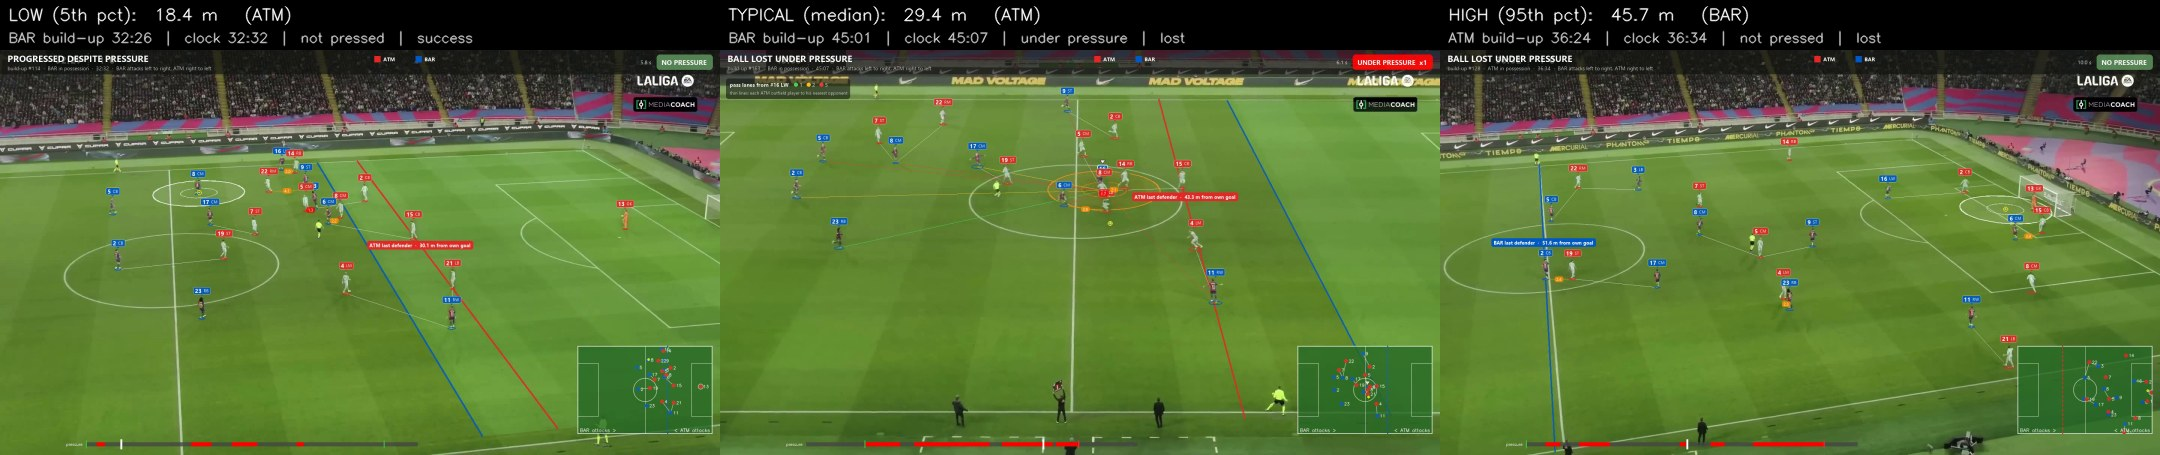

   LOW (5th pct)      kept_under_pressure/b114_BAR_32-26.mp4  clip frame 53  (tracking frame 48800)
   TYPICAL (median)   lost_under_pressure/b163_BAR_45-01.mp4  clip frame 202  (tracking frame 67691)
   HIGH (95th pct)    lost_under_pressure/b128_ATM_36-24.mp4  clip frame 243  (tracking frame 54873)
Block width   [def_width]
   horizontal spread of the outfield players: smaller = narrower
   average: ATM 39.1 m | BAR 38.8 m   (defending team)


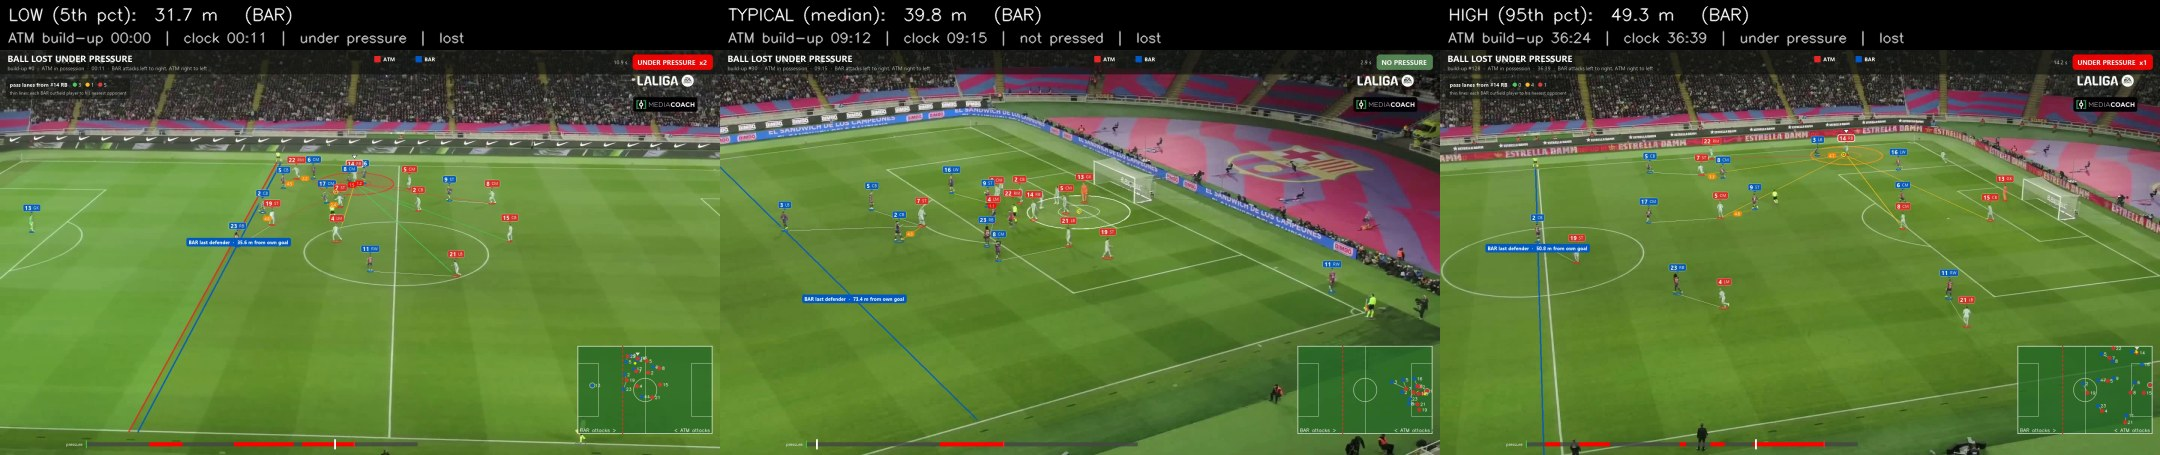

   LOW (5th pct)      lost_under_pressure/b000_ATM_00-00.mp4  clip frame 197  (tracking frame 284)
   TYPICAL (median)   lost_under_pressure/b030_ATM_09-12.mp4  clip frame 4  (tracking frame 13879)
   HIGH (95th pct)    lost_under_pressure/b128_ATM_36-24.mp4  clip frame 347  (tracking frame 54977)
Block area (convex hull)   [def_hull_area]
   area covered by the outfield players: smaller = more compact
   average: ATM 743.7 m2 | BAR 801.3 m2   (defending team)


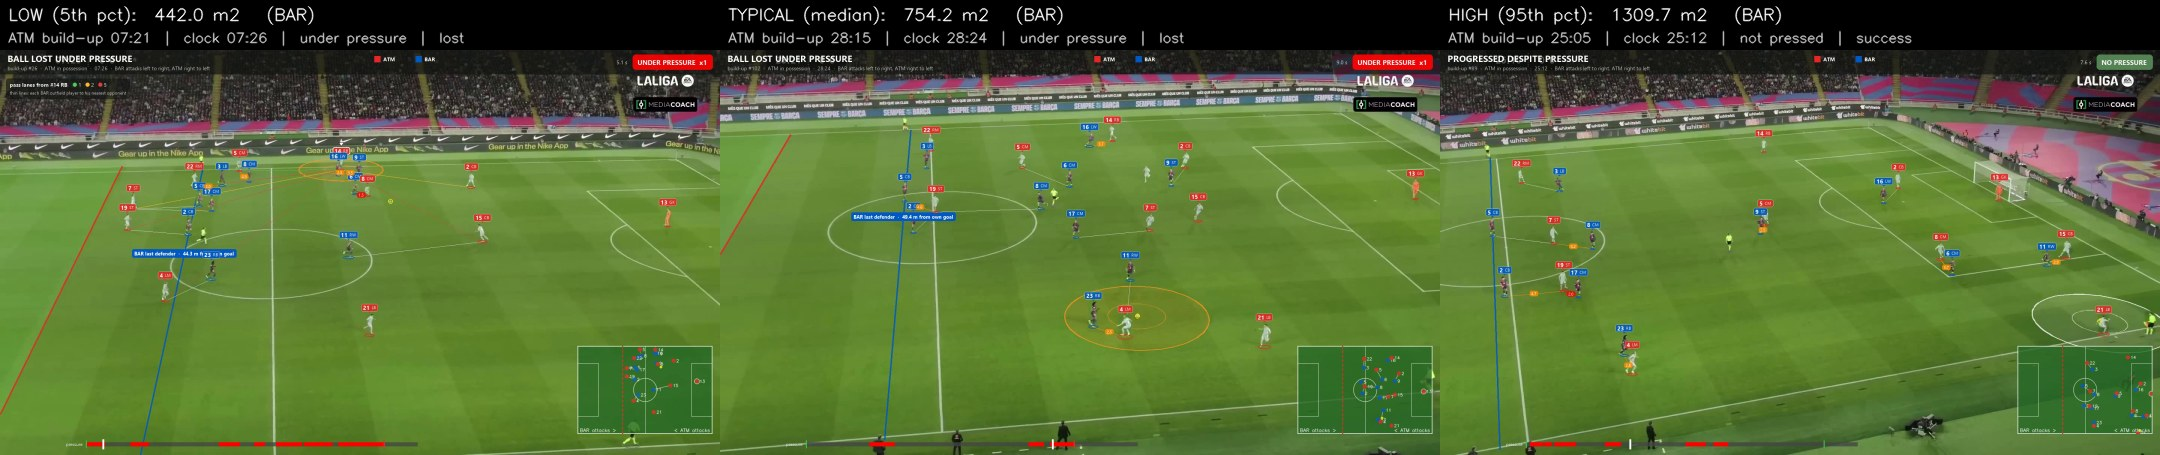

   LOW (5th pct)      lost_under_pressure/b026_ATM_07-21.mp4  clip frame 26  (tracking frame 11154)
   TYPICAL (median)   lost_under_pressure/b102_ATM_28-15.mp4  clip frame 195  (tracking frame 42614)
   HIGH (95th pct)    kept_under_pressure/b089_ATM_25-05.mp4  clip frame 157  (tracking frame 37818)
Gap back 4 to middle 3   [gap_back_mid]
   spacing between the back four and the three players above them
   average: ATM 10.2 m | BAR 11.3 m   (defending team)


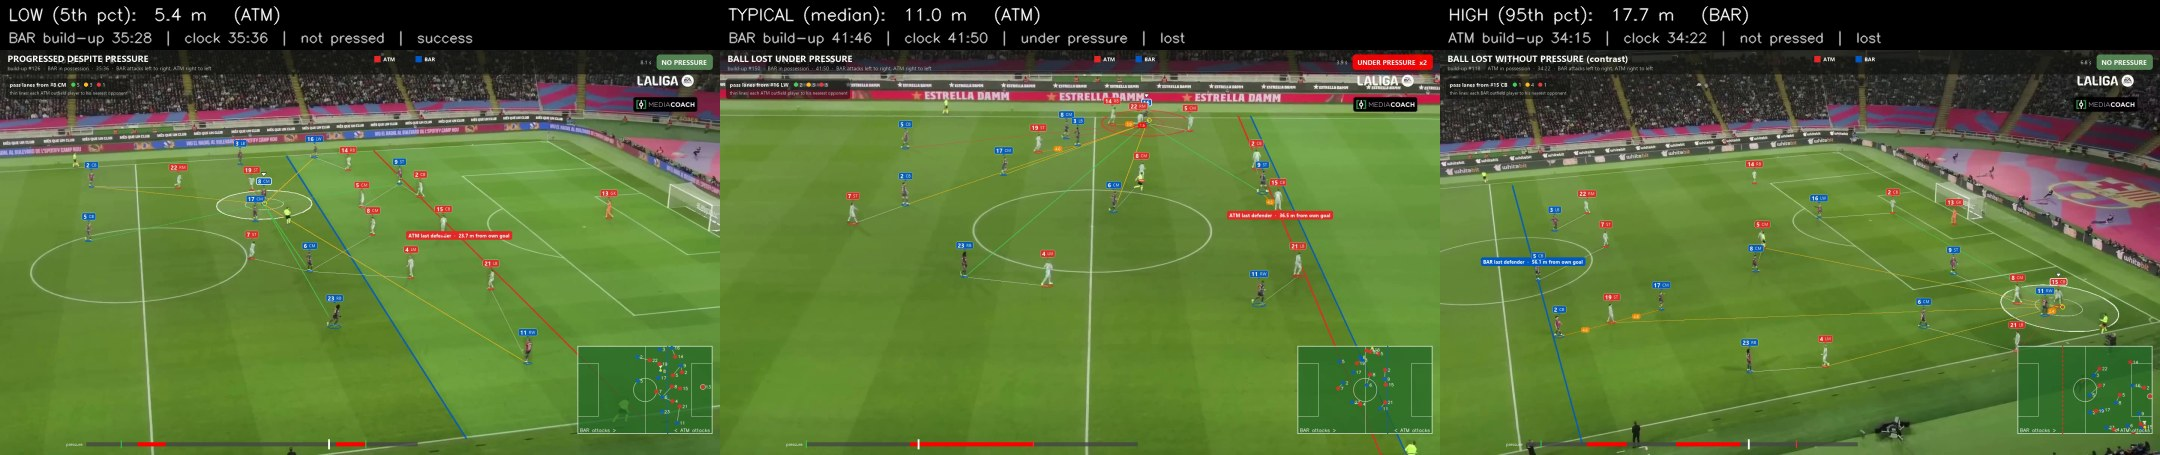

   LOW (5th pct)      kept_under_pressure/b126_BAR_35-28.mp4  clip frame 236  (tracking frame 53416)
   TYPICAL (median)   lost_under_pressure/b150_BAR_41-46.mp4  clip frame 54  (tracking frame 62770)
   HIGH (95th pct)    lost_without_pressure/b118_ATM_34-15.mp4  clip frame 182  (tracking frame 51556)
Gap middle 3 to front 3   [gap_mid_front]
   spacing between the middle three and the three highest players
   average: ATM 10.4 m | BAR 10.8 m   (defending team)


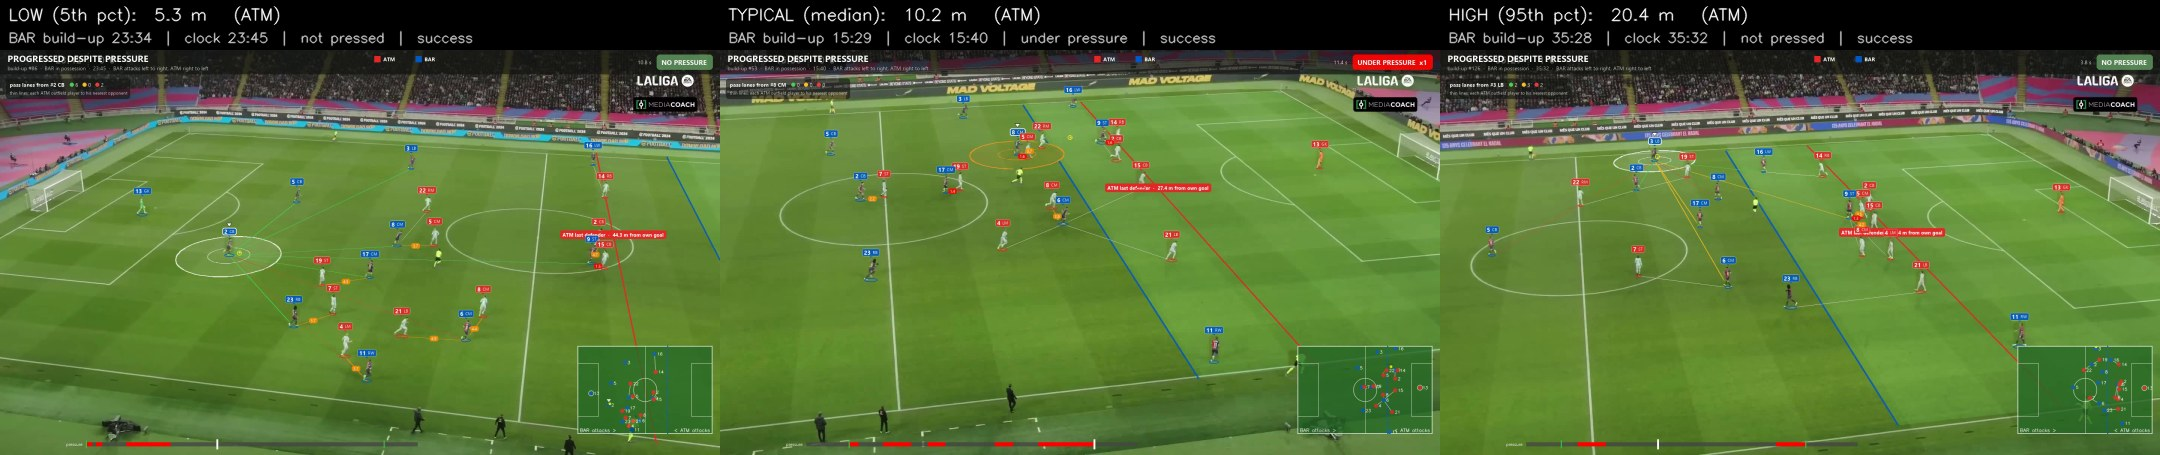

   LOW (5th pct)      kept_under_pressure/b086_BAR_23-34.mp4  clip frame 198  (tracking frame 35628)
   TYPICAL (median)   kept_under_pressure/b053_BAR_15-29.mp4  clip frame 336  (tracking frame 23523)
   HIGH (95th pct)    kept_under_pressure/b126_BAR_35-28.mp4  clip frame 128  (tracking frame 53308)
Defenders within 15 m of the ball   [def_n_local]
   how many defenders are near the ball (local compression)
   average: ATM 2.8 n | BAR 3.0 n   (defending team)


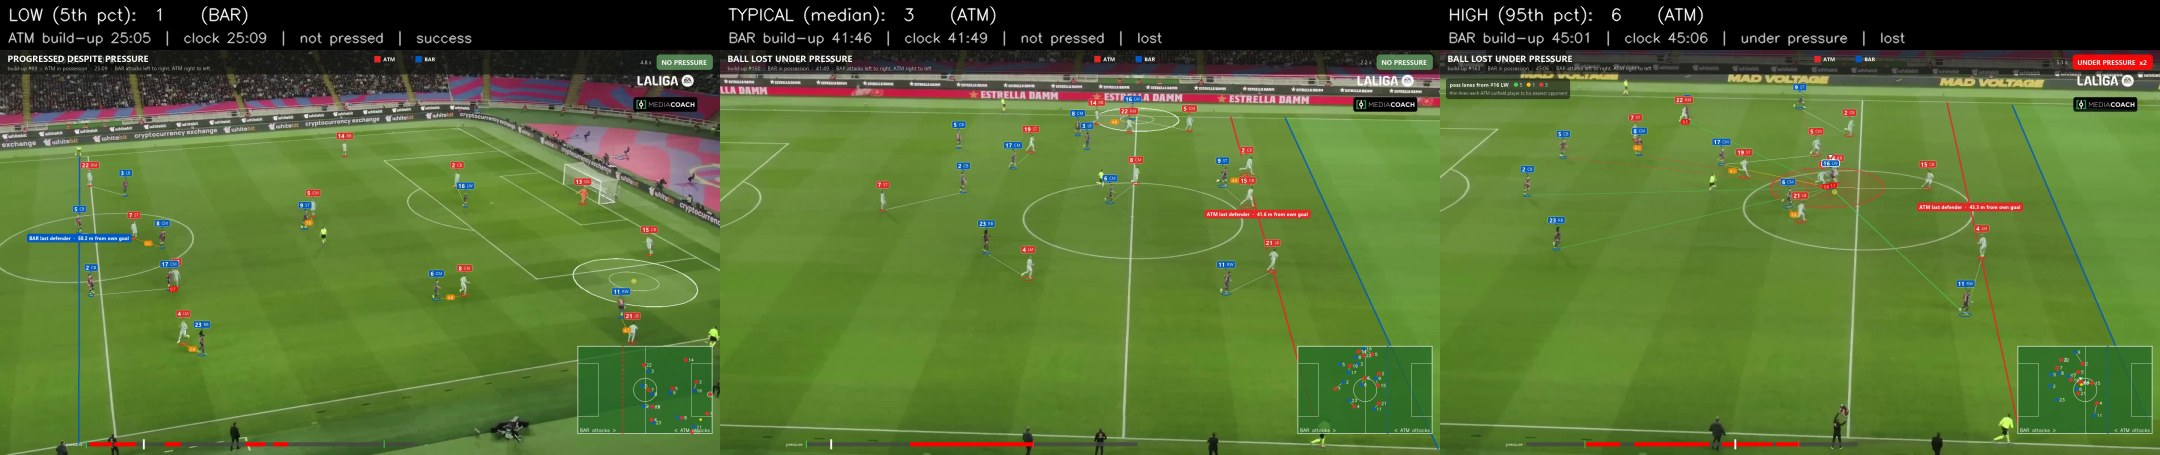

   LOW (5th pct)      kept_under_pressure/b089_ATM_25-05.mp4  clip frame 87  (tracking frame 37748)
   TYPICAL (median)   lost_under_pressure/b150_BAR_41-46.mp4  clip frame 12  (tracking frame 62728)
   HIGH (95th pct)    lost_under_pressure/b163_BAR_45-01.mp4  clip frame 178  (tracking frame 67667)
Local balance within 15 m (defenders minus build-up players)   [local_superiority]
   positive = defenders outnumber the build-up team around the ball
   average: ATM -0.6 n | BAR -0.3 n   (defending team)


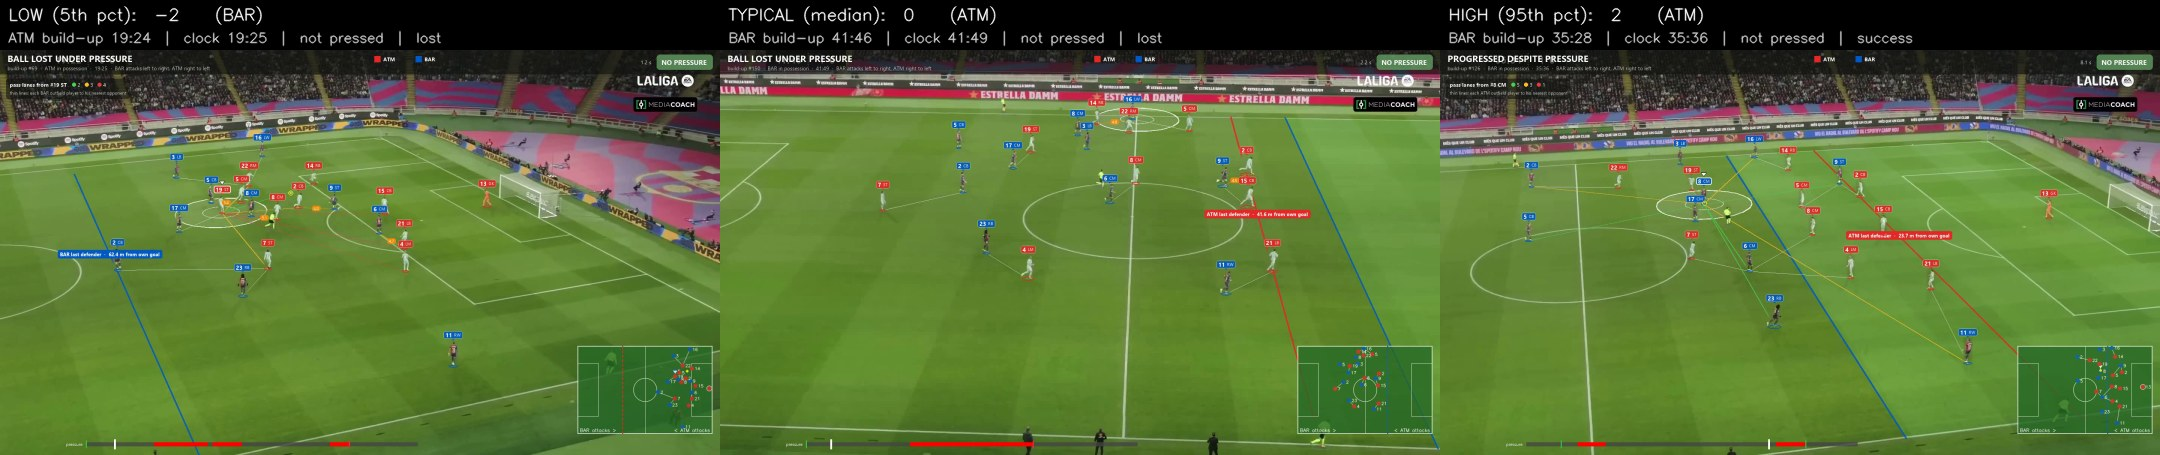

   LOW (5th pct)      lost_under_pressure/b069_ATM_19-24.mp4  clip frame 21  (tracking frame 29137)
   TYPICAL (median)   lost_under_pressure/b150_BAR_41-46.mp4  clip frame 12  (tracking frame 62728)
   HIGH (95th pct)    kept_under_pressure/b126_BAR_35-28.mp4  clip frame 236  (tracking frame 53416)
Distance carrier to nearest defender   [min_dist]
   from the pressure measurement
   average: ATM 6.8 m | BAR 6.4 m   (defending team)


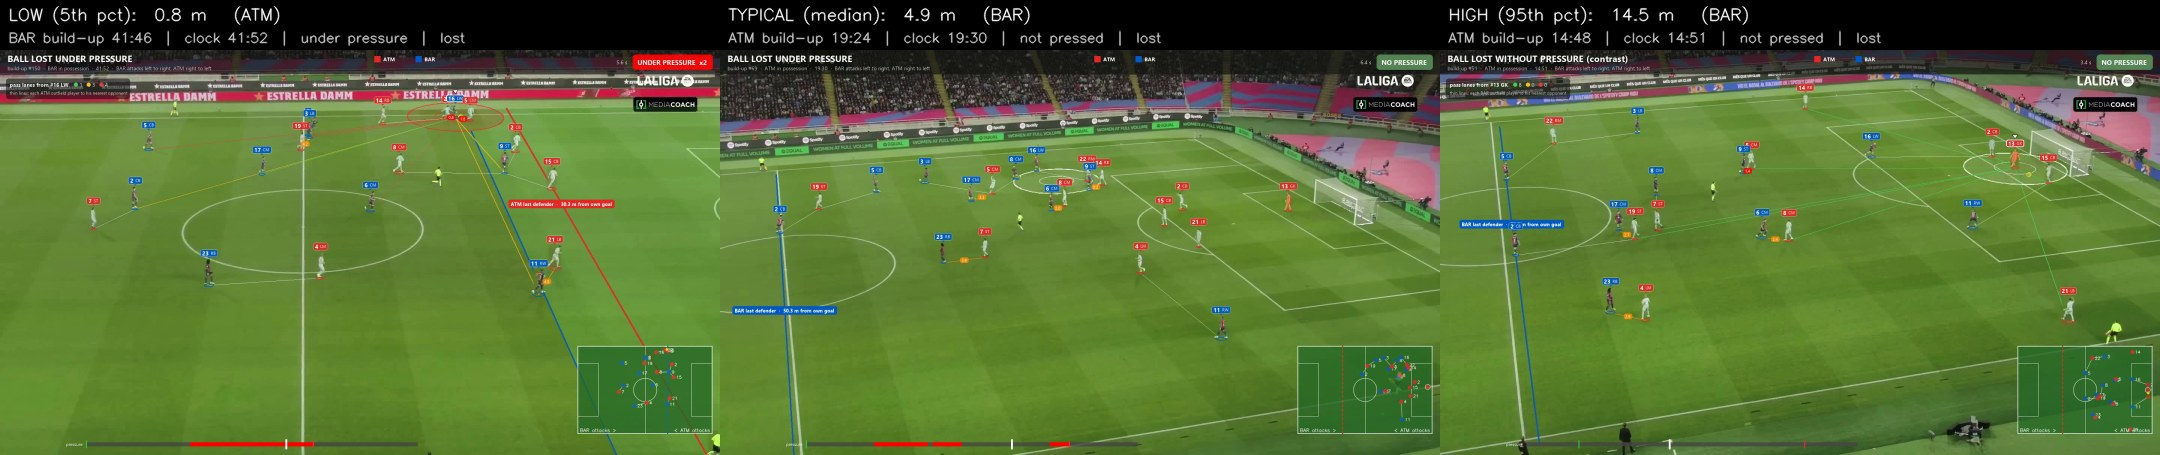

   LOW (5th pct)      lost_under_pressure/b150_BAR_41-46.mp4  clip frame 96  (tracking frame 62812)
   TYPICAL (median)   lost_under_pressure/b069_ATM_19-24.mp4  clip frame 151  (tracking frame 29267)
   HIGH (95th pct)    lost_without_pressure/b051_ATM_14-48.mp4  clip frame 136  (tracking frame 22299)
Pressers (pressed frames only)   [n_pressing]
   defenders meeting the press rule at the same time
   average: ATM 1.1 n | BAR 1.2 n   (defending team)


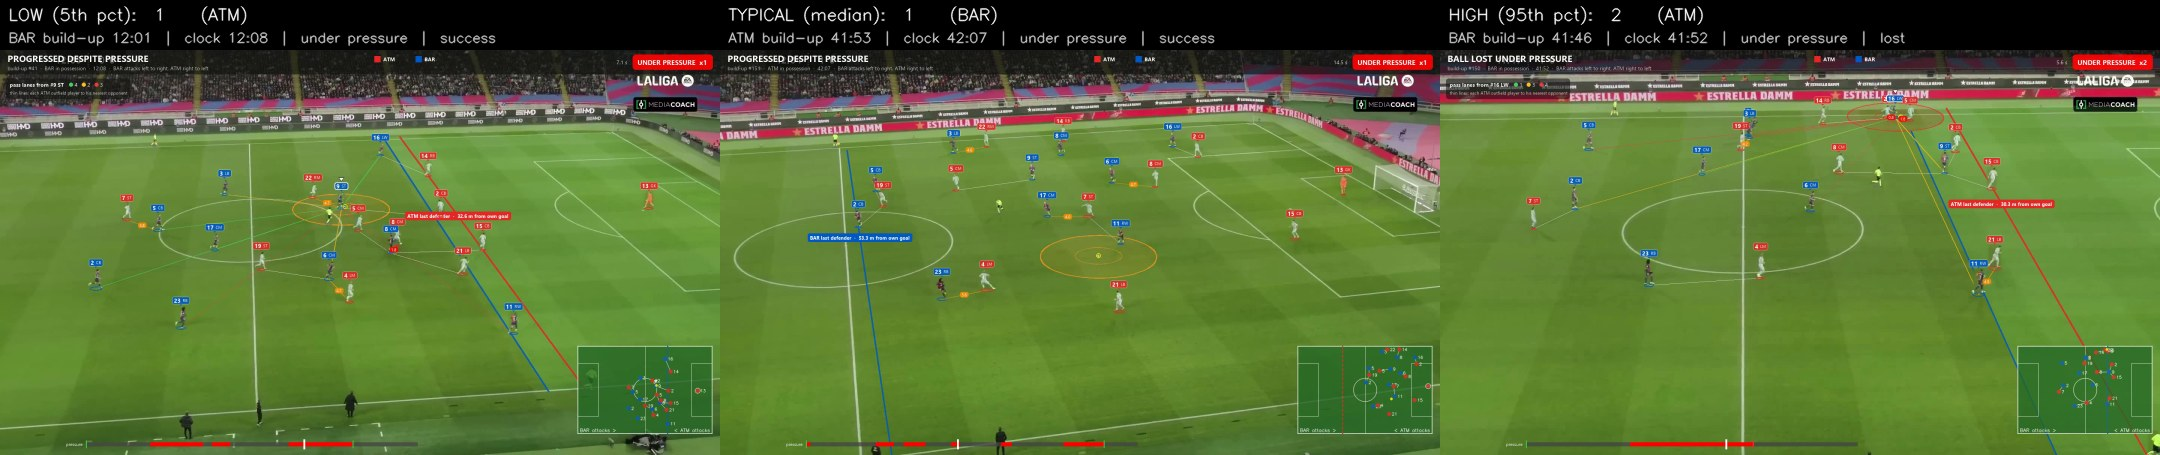

   LOW (5th pct)      kept_under_pressure/b041_BAR_12-01.mp4  clip frame 170  (tracking frame 18207)
   TYPICAL (median)   kept_under_pressure/b151_ATM_41-53.mp4  clip frame 229  (tracking frame 63188)
   HIGH (95th pct)    lost_under_pressure/b150_BAR_41-46.mp4  clip frame 96  (tracking frame 62812)
Build-up team width   [att_width]
   horizontal spread of the team in possession
   average: ATM 41.6 m | BAR 47.8 m   (team building up)


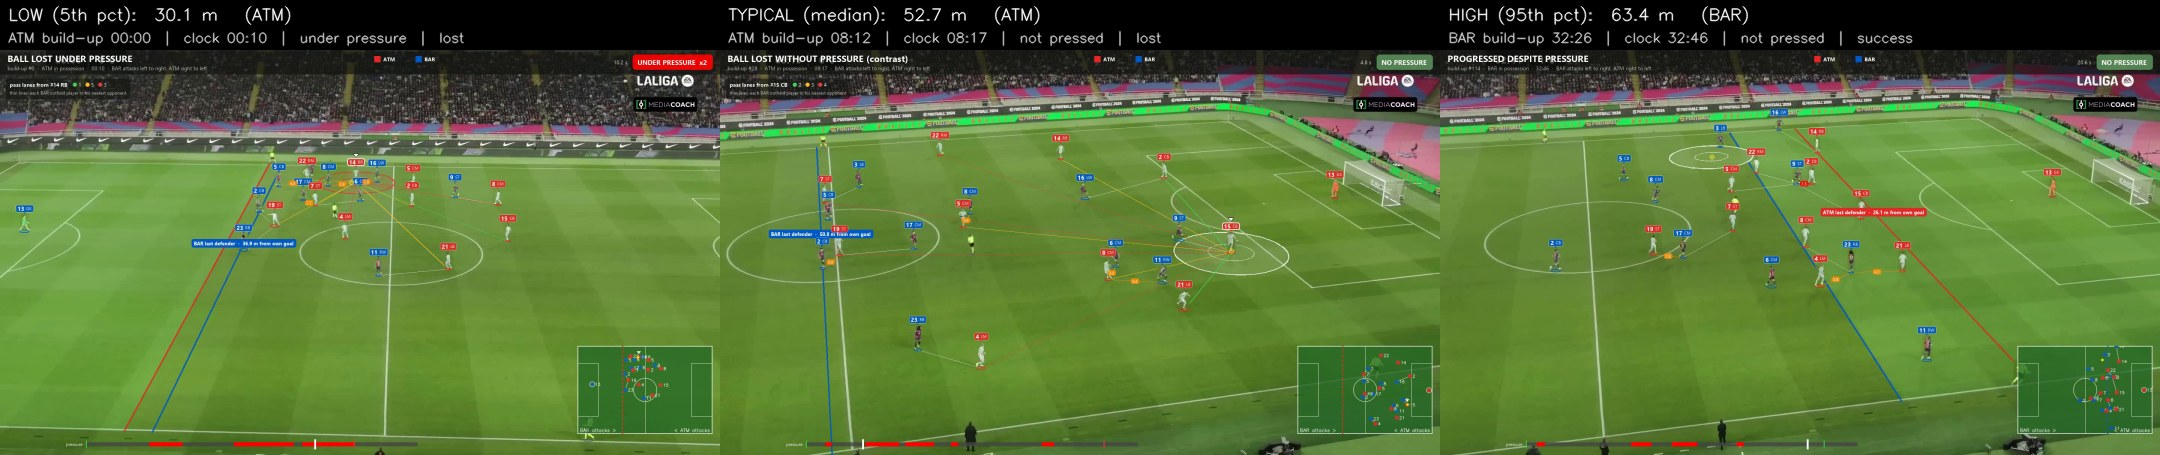

   LOW (5th pct)      lost_under_pressure/b000_ATM_00-00.mp4  clip frame 181  (tracking frame 268)
   TYPICAL (median)   lost_without_pressure/b028_ATM_08-12.mp4  clip frame 86  (tracking frame 12441)
   HIGH (95th pct)    kept_under_pressure/b114_BAR_32-26.mp4  clip frame 425  (tracking frame 49172)
Build-up team depth   [att_depth]
   length of the team in possession, last player to highest
   average: ATM 29.2 m | BAR 30.4 m   (team building up)


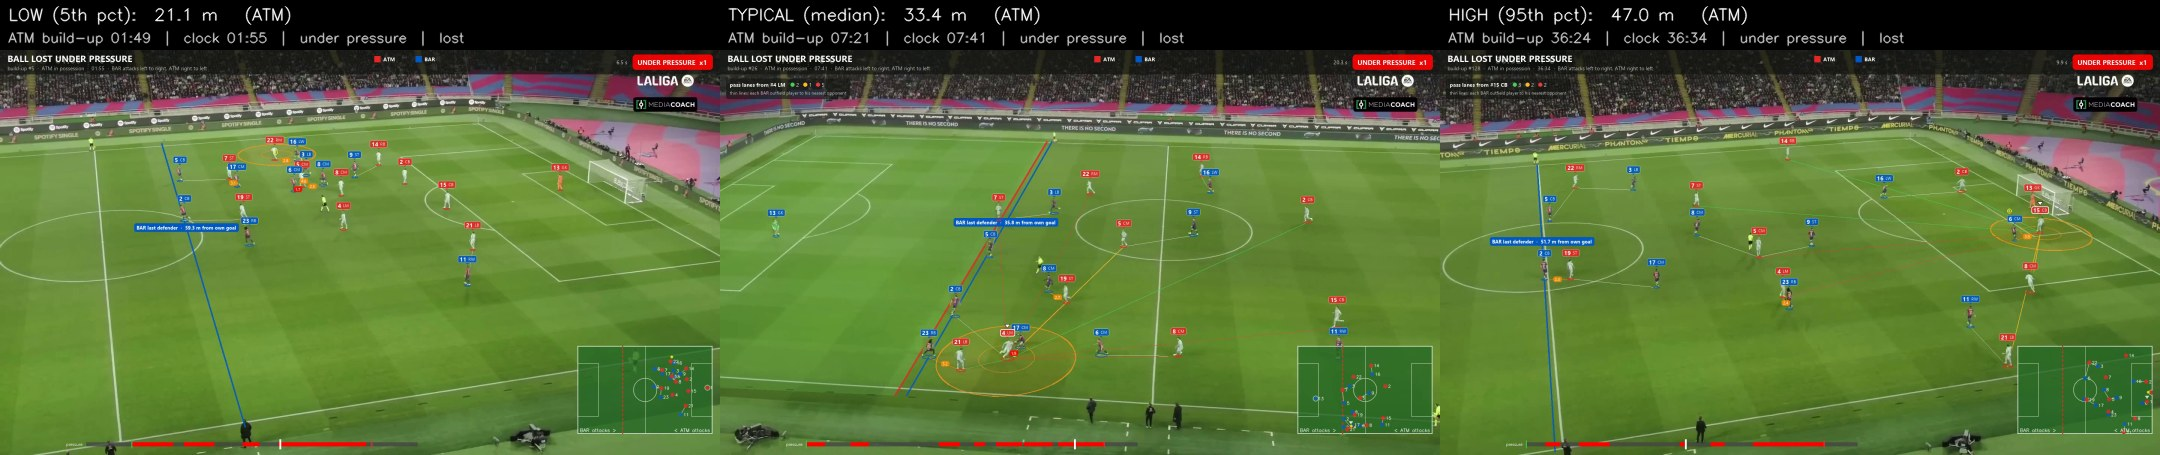

   LOW (5th pct)      lost_under_pressure/b005_ATM_01-49.mp4  clip frame 212  (tracking frame 2898)
   TYPICAL (median)   lost_under_pressure/b026_ATM_07-21.mp4  clip frame 406  (tracking frame 11534)
   HIGH (95th pct)    lost_under_pressure/b128_ATM_36-24.mp4  clip frame 241  (tracking frame 54871)

13 example sheets saved to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\shape_press_stats\examples


In [6]:
# ================================================================== 6. Annotated frame examples for every metric
# For each metric with example=True: three real frames from the annotated clips, at the metric's LOW (5th percentile), TYPICAL (median) and HIGH
# (95th percentile) value among the frames that have a usable clip. The three frames come from three different build-ups. The clips already show the
# v5 annotation (number + position tags, carrier, ball, defensive line, press radius, minimap). The caption of each tile gives the measured value;
# check it against the clip's own clock in the header (tracking clock in the caption = clock shown on the clip).
from IPython.display import display, Image as IPImage
QUANTS = [(0.05, "LOW (5th pct)"), (0.50, "TYPICAL (median)"), (0.95, "HIGH (95th pct)")]
TILE_W = 720                       # width of each tile in the sheet (the sheet is saved at this size)
DISPLAY_W = 1500                   # width shown in the notebook
EXAMPLE_TEAM = None                # None = both teams, or "ATM" / "BAR": examples only where that team is the one the metric describes
ONLY_METRICS = None                # None = all, or a list such as ["def_line_height", "def_width"]
SEED = 7
EX_DIR = STATS_DIR / "examples"; EX_DIR.mkdir(exist_ok=True)
assert len(clip_index) and clip_index.frames_ok.any(), "no usable clips: run cell 5 and check CLIP_FOLDER"

usable = clip_index[clip_index.frames_ok][["buildup_id", "path", "f0", "n_clip"]]
el = fs.merge(usable, on="buildup_id").merge(buildups[["buildup_id", "start_time", "outcome"]], on="buildup_id")
el["clip_k"] = (el.frame_idx - el.f0) * SLOWDOWN
el = el[(el.frame_idx >= el.f0) & (el.clip_k < el.n_clip)].copy()
el["rnd"] = np.random.default_rng(SEED).random(len(el))
print(f"{len(el):,} candidate frames from {el.buildup_id.nunique()} build-ups with a usable clip\n")

def pick_examples(e, key):
    e = e[e[key].notna()]
    if e[key].nunique() < 2 or e.buildup_id.nunique() < len(QUANTS):
        return []
    step = max(e[key].std() * 0.05, 1e-6); used, out = set(), []
    for q, label in QUANTS:
        v = e[key].quantile(q)
        c = e.assign(dv=((e[key] - v).abs() / step).round()).sort_values(["dv", "rnd"])      # near-ties are broken at random, not by frame order
        c = c[~c.buildup_id.isin(used)]
        if c.empty:
            continue
        r = c.iloc[0]; used.add(r.buildup_id); out.append((label, r))
    return out

def make_tile(r, label, m):
    cap = cv2.VideoCapture(str(r.path)); cap.set(cv2.CAP_PROP_POS_FRAMES, int(r.clip_k)); ok, img = cap.read(); cap.release()
    if not ok:
        return None
    img = cv2.resize(img, (TILE_W, int(img.shape[0] * TILE_W / img.shape[1])), interpolation=cv2.INTER_AREA)
    val = r[m["key"]]; vtxt = f"{val:.0f}" if m["unit"] == "n" else f"{val:.1f}"
    who = r["def_team_name"] if m["group"] == "def" else r["poss_team_name"]
    bar = np.zeros((50, TILE_W, 3), np.uint8)
    cv2.putText(bar, f"{label}:  {vtxt} {'' if m['unit'] == 'n' else m['unit']}   ({who})", (8, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    cv2.putText(bar, f"{TEAM_NAMES[int(r.poss_team)]} build-up {r.start_time}  |  clock {mmss(r.frame_idx)}  |  {'under pressure' if r.under_pressure else 'not pressed'}  |  {r.outcome}",
                (8, 42), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 200, 200), 1, cv2.LINE_AA)
    return np.vstack([bar, img])

shown = 0
for m in METRICS:
    if not m["example"] or (ONLY_METRICS and m["key"] not in ONLY_METRICS):
        continue
    e = el[el.under_pressure] if m["pressed_only"] else el
    if EXAMPLE_TEAM:
        e = e[e[tcol(m)] == EXAMPLE_TEAM]
    ex = pick_examples(e, m["key"])
    avg = tabA[tabA.metric == m["key"]].iloc[0]
    print("=" * 110)
    print(f"{m['label']}   [{m['key']}]\n   {m['what']}\n   average: " + " | ".join(f"{t} {avg[t]} {m['unit']}" for t in team_list) + f"   ({avg['who']})")
    if not ex:
        print("   not enough distinct build-ups with clips for examples"); continue
    tiles = [t for t in (make_tile(r, lab, m) for lab, r in ex) if t is not None]
    if not tiles:
        print("   could not read the clip frames"); continue
    sheet = np.hstack(tiles)
    out = EX_DIR / f"{m['key']}.jpg"; cv2.imwrite(str(out), sheet, [cv2.IMWRITE_JPEG_QUALITY, 88])
    ok_, buf = cv2.imencode(".jpg", sheet, [cv2.IMWRITE_JPEG_QUALITY, 88]); display(IPImage(data=buf.tobytes(), width=DISPLAY_W))
    for lab, r in ex:
        print(f"   {lab:18s} {r.path.parent.name}/{r.path.name}  clip frame {int(r.clip_k)}  (tracking frame {int(r.frame_idx)})")
    shown += 1
print(f"\n{shown} example sheets saved to {EX_DIR}")
